In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [102]:
df = pd.read_csv("height_weight.csv")

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df.head()

,Height_cm,Weight_kg
0,150,45
1,155,50
2,158,53
3,160,55
4,162,57


In [103]:
y = df["Weight_kg"]
X = df["Height_cm"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

X_train

1     155
22    190
5     164
2     158
12    176
15    181
3     160
4     162
20    187
17    183
21    188
18    185
24    195
7     168
10    174
14    180
19    186
6     166
Name: Height_cm, dtype: int64

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values.reshape(-1, 1))
X_test_scaled = scaler.transform(X_test.values.reshape(-1, 1))

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [105]:
print(f"The slope or coefficient of weight is: {linreg.coef_}")
print(f"The Intercept is: {linreg.intercept_}")

The slope or coefficient of weight is: [15.87746815]
The Intercept is: 75.16666666666669


In [106]:
from sklearn.metrics import r2_score, mean_absolute_error

print(f"The R Squared Score is : {r2_score(y_test, linreg.predict(X_test_scaled))}")
print(f"The Mean Absolute Error is : {mean_absolute_error(y_test, linreg.predict(X_test_scaled))}")

The R Squared Score is : 0.9905670797379759
The Mean Absolute Error is : 1.1304812055618914


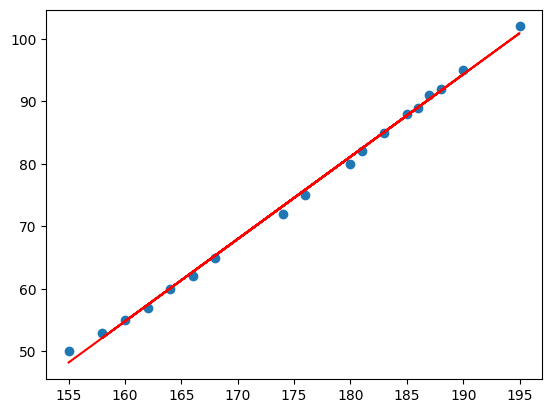

In [107]:
plt.scatter(X_train, y_train)
plt.plot(X_train, linreg.predict(X_train_scaled), color='red')

In [108]:
def predict(height):
    scaled_height = scaler.transform([[height]])
    
    predicted_weight = linreg.predict(scaled_height)[0]
    
    return f"The predicted Weight for Height {height}cm is: {predicted_weight:.2f}kg"

In [110]:
predict(178)

'The predicted Weight for Height 178cm is: 78.53kg'